# 02_RQ2_Advanced_Model_Comparison
Objective and methodology.

# ============================================
# RQ2: Model Comparison 
# ============================================

In [1]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# XGBoost (important)
from xgboost import XGBClassifier


# ============================================
# 2. Create Output Folder
# ============================================

In [2]:
os.makedirs('outputs', exist_ok=True)

# ============================================
# 3. Load Dataset
# ============================================

In [3]:
df = pd.read_csv('marketing_and_product_performance.csv')

# ============================================
# 4. Feature Engineering 
# ============================================

In [4]:
df['Conversion_Rate'] = df['Conversions'] / df['Clicks']
df['Conversion_Rate'] = df['Conversion_Rate'].replace([np.inf, -np.inf], np.nan).fillna(0)

def categorize(rate):
    if rate < 0.02:
        return 'Low'
    elif rate < 0.05:
        return 'Medium'
    else:
        return 'High'

df['Target'] = df['Conversion_Rate'].apply(categorize)

le = LabelEncoder()
df['Target'] = le.fit_transform(df['Target'])

df = df.drop(columns=['Conversion_Rate'], errors='ignore')



# ============================================
# 5. Preprocessing
# ============================================

In [5]:
X = df.drop(columns=['Target'])
y = df['Target']

X = pd.get_dummies(X, drop_first=True)
X = X.iloc[:, :40]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ============================================
# 6. Models
# ============================================

In [9]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    n_jobs=-1,
    random_state=42
     ),
    "SVM": SVC(kernel='linear', probability=False),
    "XGBoost": XGBClassifier(
    n_estimators=50,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    n_jobs=-1
     )
}

results = []

# For ROC Curve
y_test_bin = label_binarize(y_test, classes=np.unique(y))

plt.figure(figsize=(8,6))

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

# ============================================
# 7. Training + Evaluation
# ============================================

In [ ]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append([name, acc, prec, rec, f1])


# ============================================
# 8. Results Table
# ============================================

In [ ]:
results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1-score"
])

print("\nModel Comparison Results:\n")
print(results_df)

# Save table
results_df.to_csv('RQ2_outputs/RQ2_Model_Comparison.csv', index=False)



Model Comparison Results:

                 Model  Accuracy  Precision  Recall  F1-score
0  Logistic Regression    0.9890   0.989228  0.9890  0.988949
1        Random Forest    0.9645   0.963139  0.9645  0.962092
2                  SVM    0.9920   0.992104  0.9920  0.992009
3              XGBoost    0.9930   0.993092  0.9930  0.993037


# ============================================
# 9. Simple Visualization
# ============================================


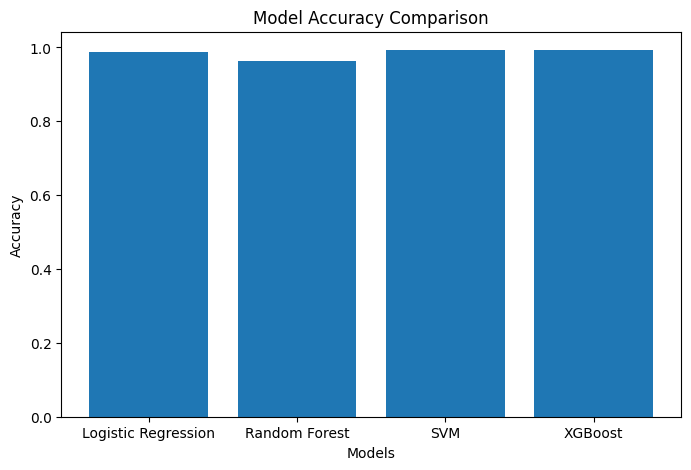

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.savefig('RQ2_outputs/RQ2_Model_Comparison.pdf')
plt.show()

# ============================================
# 10. Best Model
# ============================================

In [17]:
best_model = results_df.sort_values(by="F1-score", ascending=False).iloc[0]

print("\nBest Model:")
print(best_model)


Best Model:
Model         XGBoost
Accuracy        0.993
Precision    0.993092
Recall          0.993
F1-score     0.993037
Name: 3, dtype: object
